In [3]:
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_ind

##### COH

In [ ]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def vec2mat(vec, n_chan):
    mat = np.zeros((n_chan, n_chan))
    iu = np.triu_indices(n_chan, 1)
    mat[iu] = vec
    mat[(iu[1], iu[0])] = vec
    return mat

root      = Path("../data")
BD_coh    = load_pickle(root / "COH" / "BD_coh_data.pkl")
MDD_coh   = load_pickle(root / "COH" / "MDD_coh_data.pkl")
freqs     = ["delta", "theta", "alpha", "betalow", "betahigh", "gamma"]
thresholds= np.arange(0.025, 0.7, 0.025)
n_rand    = 20

In [ ]:
# compute: C, Cr, L, Lr, γ, λ, S
def compute_stage_metrics(group_coh, freqs, thresholds, n_rand):
    n_chan = None
    metrics = {band: {} for band in freqs}
    for band in freqs:
        for T in thresholds:
            C_list = []
            Cr_list= []
            L_list = []
            Lr_list= []
            gamma_list = []
            lam_list   = []
            S_list     = []
            for subj in group_coh.values():
                X = subj[band]
                if X.ndim == 1:
                    # first subject we see, infer n_chan
                    if n_chan is None:
                        n_chan = int((1 + np.sqrt(1 + 8*len(X)))//2)
                    mat = vec2mat(X, n_chan)
                else:
                    mat = X
                    if n_chan is None:
                        n_chan = mat.shape[0]
                A = (mat > T).astype(int)
                if A.sum() < 2:
                    continue

                # 原網路 C, L
                G = nx.from_numpy_array(A)
                C = nx.average_clustering(G)
                dists = []
                for i, dist in nx.all_pairs_shortest_path_length(G):
                    dists.extend([d for j, d in dist.items() if j > i])
                if not dists:
                    continue
                L = np.mean(dists)

                # 隨機網路 Cr, Lr
                m_edges = int(A.sum()/2)
                Cr_subj, Lr_subj = [], []
                for _ in range(n_rand):
                    G_r = nx.gnm_random_graph(n_chan, m_edges)
                    Cr_subj.append(nx.average_clustering(G_r))
                    d_r = []
                    for i, dist in nx.all_pairs_shortest_path_length(G_r):
                        d_r.extend([d for j, d in dist.items() if j > i])
                    if d_r:
                        Lr_subj.append(np.mean(d_r))
                if not Cr_subj or not Lr_subj:
                    continue
                Cr = np.mean(Cr_subj)
                Lr = np.mean(Lr_subj)
                if Cr == 0 or Lr == 0:
                    continue

                gamma = C/Cr
                lam   = L/Lr
                S     = gamma/lam


                C_list.append(C)
                Cr_list.append(Cr)
                L_list.append(L)
                Lr_list.append(Lr)
                gamma_list.append(gamma)
                lam_list.append(lam)
                S_list.append(S)

            metrics[band][T] = {
                'C':    C_list,
                'Cr':   Cr_list,
                'L':    L_list,
                'Lr':   Lr_list,
                'gamma':gamma_list,
                'lam':  lam_list,
                'S':    S_list
            }
    return metrics

metrics_BD  = compute_stage_metrics(BD_coh,  freqs, thresholds, n_rand)
metrics_MDD = compute_stage_metrics(MDD_coh, freqs, thresholds, n_rand)


In [4]:
### save metrics
with open("../result_FA/svalue/COH/metrics_BD.pkl", 'wb') as f:
    pickle.dump(metrics_BD, f)
with open("../result_FA/svalue/COH/metrics_MDD.pkl", 'wb') as f:
    pickle.dump(metrics_MDD, f)

In [5]:
### load metrics
with open("../result_FA/svalue/COH/metrics_BD.pkl", 'rb') as f:
    metrics_BD = pickle.load(f)
with open("../result_FA/svalue/COH/metrics_MDD.pkl", 'rb') as f:
    metrics_MDD = pickle.load(f)

c:\Users\Well\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


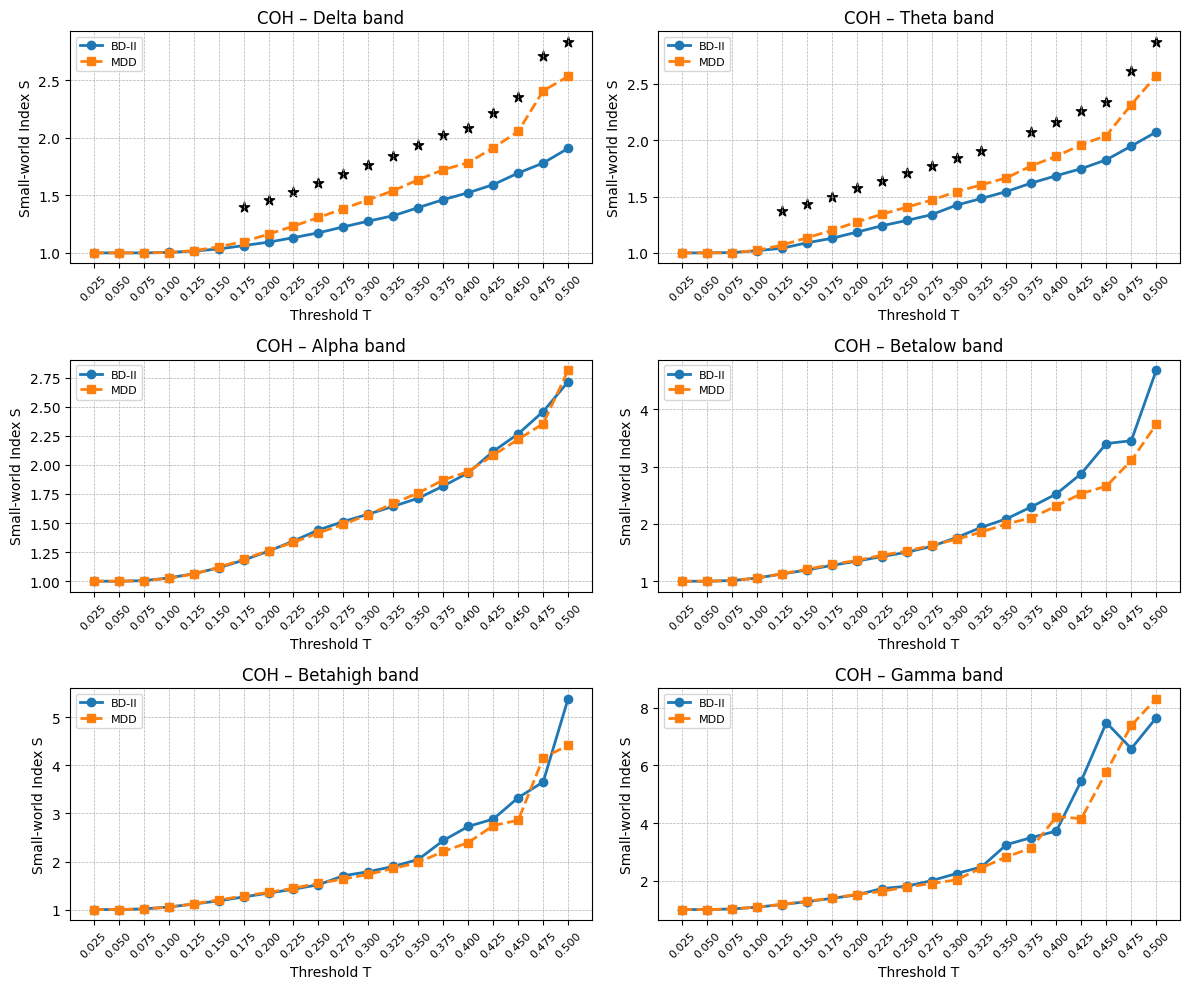

In [ ]:
# analysis
summary_coh = {band: {} for band in freqs}
signif_coh  = {band: [] for band in freqs}

for band in freqs:
    # print(f"\n=== Band: {band} ===")
    for T in thresholds:
        mb = metrics_BD[band][T]
        mm = metrics_MDD[band][T]

        if not mb['S'] or not mm['S']:
            summary_coh[band][T] = None
            signif_coh[band].append(False)
            # print(f"T={T:.3f}: insufficient data, skipped")
            continue

        # group averages
        mC_b = np.mean(mb['C']);   mCr_b = np.mean(mb['Cr'])
        mL_b = np.mean(mb['L']);   mLr_b = np.mean(mb['Lr'])
        mg_b = np.mean(mb['gamma']);  ml_b = np.mean(mb['lam'])
        mS_b = np.mean(mb['S'])

        mC_m = np.mean(mm['C']);   mCr_m = np.mean(mm['Cr'])
        mL_m = np.mean(mm['L']);   mLr_m = np.mean(mm['Lr'])
        mg_m = np.mean(mm['gamma']);  ml_m = np.mean(mm['lam'])
        mS_m = np.mean(mm['S'])

        # t test
        stat, p = ttest_ind(mb['S'], mm['S'], equal_var=False)
        flag = (p < 0.05)
        signif_coh[band].append(flag)


        summary_coh[band][T] = {
            'mean_C_BD':   mC_b,  'mean_Cr_BD':  mCr_b,
            'mean_L_BD':   mL_b,  'mean_Lr_BD':  mLr_b,
            'mean_gamma_BD': mg_b,'mean_lam_BD': ml_b,
            'mean_S_BD':   mS_b,

            'mean_C_MDD':   mC_m,  'mean_Cr_MDD':  mCr_m,
            'mean_L_MDD':   mL_m,  'mean_Lr_MDD':  mLr_m,
            'mean_gamma_MDD': mg_m,'mean_lam_MDD': ml_m,
            'mean_S_MDD':    mS_m,

            't_stat': stat, 'p_val': p
        }


        star = "*" if flag else ""
        # print((
        #     f"T={T:.3f}: "
        #     f"BD C={mC_b:.3f},Cr={mCr_b:.3f},L={mL_b:.3f},Lr={mLr_b:.3f},"
        #     f"γ={mg_b:.3f},λ={ml_b:.3f},S={mS_b:.3f} | "
        #     f"MDD C={mC_m:.3f},Cr={mCr_m:.3f},L={mL_m:.3f},Lr={mLr_m:.3f},"
        #     f"γ={mg_m:.3f},λ={ml_m:.3f},S={mS_m:.3f} | "
        #     f"t={stat:.3f},p={p:.3f}{star}"
        # ))




# plot
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, band in zip(axes, freqs):
    x      = thresholds[:20]
    y_bd   = [summary_coh[band][T]['mean_S_BD']   if summary_coh[band][T] else np.nan for T in x]
    y_mdd  = [summary_coh[band][T]['mean_S_MDD']  if summary_coh[band][T] else np.nan for T in x]
    sigs   = signif_coh[band]

    ax.plot(x, y_bd,  label='BD-II', linewidth=2, marker='o')
    ax.plot(x, y_mdd, linestyle='--', label='MDD', linewidth=2, marker='s')

    # star
    for xi, bd_i, mdd_i, sig in zip(x, y_bd, y_mdd, sigs):
        if sig:
            y_star = max(bd_i, mdd_i) + 0.3
            ax.scatter(xi, y_star, marker='*', color='black', s=60)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.3f}" for t in x], rotation=45, fontsize=8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5)

    # plot value
    # for xi, yi in zip(x, y_bd):
    #     ax.text(xi, yi, f"{yi:.2f}", fontsize=6, va='bottom', ha='right')
    # for xi, yi in zip(x, y_mdd):
    #     ax.text(xi, yi, f"{yi:.2f}", fontsize=6, va='bottom', ha='left')

    ax.set_title(f'COH – {band.capitalize()} band')
    ax.set_xlabel('Threshold T')
    ax.set_ylabel('Small-world Index S')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


##### PLI

In [ ]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def vec2mat(vec, n_chan):
    mat = np.zeros((n_chan, n_chan))
    iu = np.triu_indices(n_chan, 1)
    mat[iu] = vec
    mat[(iu[1], iu[0])] = vec
    return mat


root       = Path("../data")
BD_pli     = load_pickle(root / "PLI" / "BD_pli_data.pkl")
MDD_pli    = load_pickle(root / "PLI" / "MDD_pli_data.pkl")
freqs      = ["delta", "theta", "alpha", "betalow", "betahigh", "gamma"]
thresholds = np.arange(0.005, 0.4, 0.005)
n_rand     = 20

In [ ]:
# compute：C, Cr, L, Lr, γ, λ, S
def compute_stage_metrics(group_pli, freqs, thresholds, n_rand):
    n_chan = None
    metrics = {band: {} for band in freqs}

    for band in freqs:
        for T in thresholds:
            C_list = []; Cr_list = []
            L_list = []; Lr_list = []
            gamma_list = []; lam_list = []; S_list = []

            for subj in group_pli.values():
                X = subj[band]
                if X.ndim == 1:
                    if n_chan is None:
                        n_chan = int((1 + np.sqrt(1 + 8*len(X)))//2)
                    mat = vec2mat(X, n_chan)
                else:
                    mat = X
                    if n_chan is None:
                        n_chan = mat.shape[0]

                A = (mat > T).astype(int)
                if A.sum() < 2:
                    continue

                # 原網路 C, L
                G = nx.from_numpy_array(A)
                C = nx.average_clustering(G)
                dists = []
                for i, dist in nx.all_pairs_shortest_path_length(G):
                    dists.extend([d for j, d in dist.items() if j > i])
                if not dists:
                    continue
                L = np.mean(dists)

                # 隨機網路 Cr, Lr
                m_edges = int(A.sum() / 2)
                Cr_subj, Lr_subj = [], []
                for _ in range(n_rand):
                    G_r = nx.gnm_random_graph(n_chan, m_edges)
                    Cr_subj.append(nx.average_clustering(G_r))
                    d_r = []
                    for i, dist in nx.all_pairs_shortest_path_length(G_r):
                        d_r.extend([d for j, d in dist.items() if j > i])
                    if d_r:
                        Lr_subj.append(np.mean(d_r))

                if not Cr_subj or not Lr_subj:
                    continue

                Cr = np.mean(Cr_subj)
                Lr = np.mean(Lr_subj)
                if Cr == 0 or Lr == 0:
                    continue

                gamma = C / Cr
                lam   = L / Lr
                S     = gamma / lam

                C_list.append(C)
                Cr_list.append(Cr)
                L_list.append(L)
                Lr_list.append(Lr)
                gamma_list.append(gamma)
                lam_list.append(lam)
                S_list.append(S)

            metrics[band][T] = {
                'C':    C_list,   'Cr':   Cr_list,
                'L':    L_list,   'Lr':   Lr_list,
                'gamma':gamma_list,'lam':  lam_list,
                'S':    S_list
            }

    return metrics


metrics_BD  = compute_stage_metrics(BD_pli,  freqs, thresholds, n_rand)
metrics_MDD = compute_stage_metrics(MDD_pli, freqs, thresholds, n_rand)

KeyboardInterrupt: 

In [ ]:
### save metrics
with open("../result_FA/svalue/PLI/metrics_BD.pkl", 'wb') as f:
    pickle.dump(metrics_BD, f)
with open("../result_FA/svalue/PLI/metrics_MDD.pkl", 'wb') as f:
    pickle.dump(metrics_MDD, f)

In [9]:
### load metrics
with open("../result_FA/svalue/PLI/metrics_BD.pkl", 'rb') as f:
    metrics_BD = pickle.load(f)
with open("../result_FA/svalue/PLI/metrics_MDD.pkl", 'rb') as f:
    metrics_MDD = pickle.load(f)

c:\Users\Well\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Well\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1081: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\Well\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1081: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


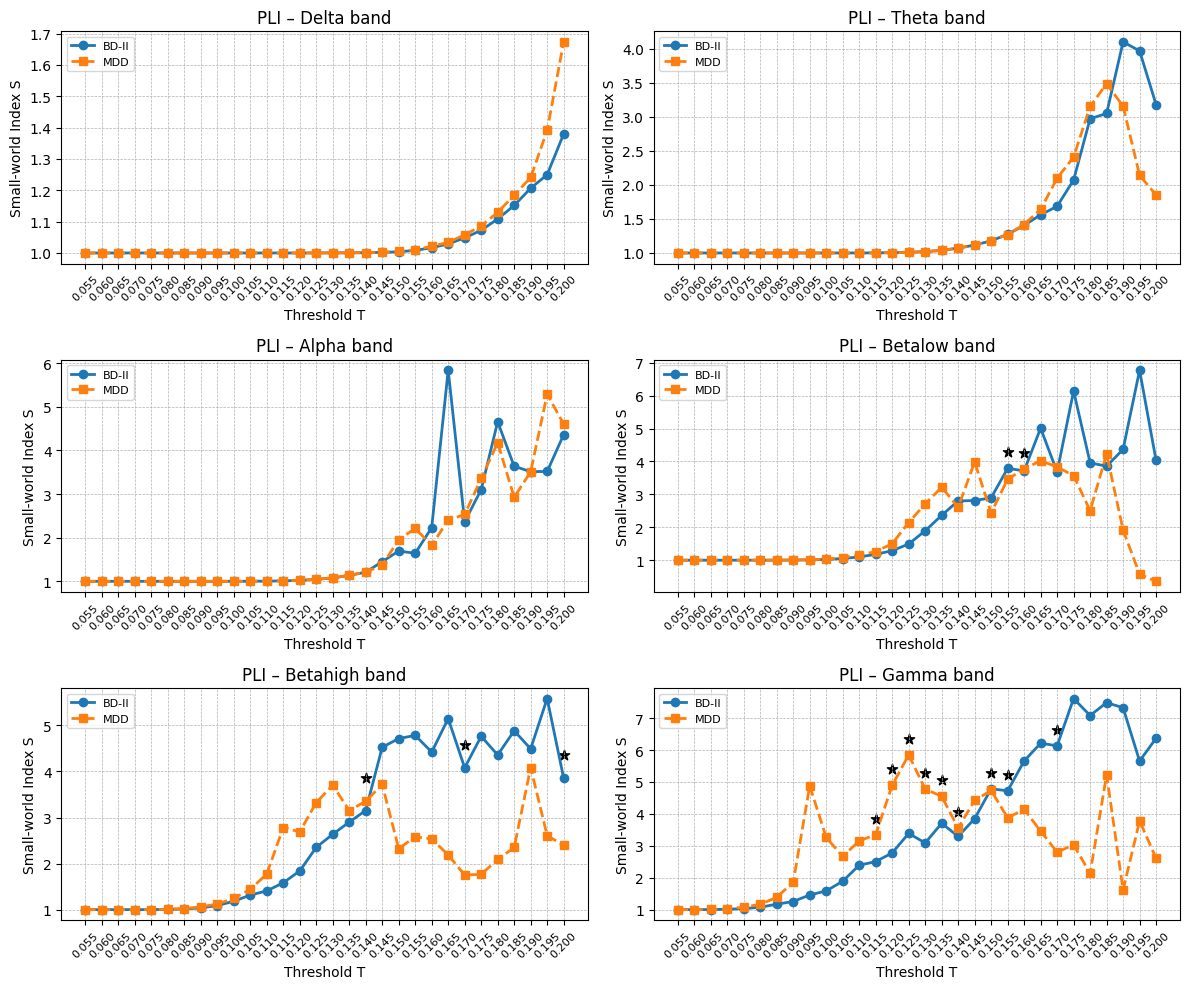

In [ ]:
summary_pli = {band: {} for band in freqs}
signif_pli  = {band: [] for band in freqs}

for band in freqs:
    for T in thresholds:
        mb = metrics_BD[band][T]
        mm = metrics_MDD[band][T]
        if not mb['S'] or not mm['S']:
            summary_pli[band][T] = None
            signif_pli[band].append(False)
            continue

        mS_b = np.mean(mb['S'])
        mS_m = np.mean(mm['S'])

        # t test
        stat, p = ttest_ind(mb['S'], mm['S'], equal_var=False)
        flag = (p < 0.05)
        signif_pli[band].append(flag)

        summary_pli[band][T] = {
            'mean_S_BD':  mS_b,
            'mean_S_MDD': mS_m,
            't_stat':     stat,
            'p_val':      p
        }

# plot
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, band in zip(axes, freqs):
    x    = thresholds[10:40]
    y_bd = [summary_pli[band][T]['mean_S_BD']  if summary_pli[band][T] else np.nan for T in x]
    y_mdd = [summary_pli[band][T]['mean_S_MDD'] if summary_pli[band][T] else np.nan for T in x]
    sigs = signif_pli[band]

    ax.plot(x, y_bd,  label='BD-II', linewidth=2, marker='o')
    ax.plot(x, y_mdd, linestyle='--', label='MDD', linewidth=2, marker='s')

    # star
    for xi, bd_i, mdd_i, sig in zip(x, y_bd, y_mdd, sigs):
        if sig:
            y_star = max(bd_i, mdd_i) + 0.5
            ax.scatter(xi, y_star, marker='*', color='black', s=60)

    ax.set_xticks(x)
    ax.set_xticklabels([f"{t:.3f}" for t in x], rotation=45, fontsize=8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5)

    ax.set_title(f'PLI – {band.capitalize()} band')
    ax.set_xlabel('Threshold T')
    ax.set_ylabel('Small-world Index S')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

##### STE

In [11]:
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def vec2dirmat(vec, n_chan):
    mat = vec.reshape((n_chan, n_chan))
    np.fill_diagonal(mat, 0)
    return mat


root       = Path("../data")
BD_ste     = load_pickle(root / "STE" / "BD_ste_data.pkl")
MDD_ste    = load_pickle(root / "STE" / "MDD_ste_data.pkl")
freqs      = ["delta", "theta", "alpha", "betalow", "betahigh", "gamma"]
thresholds = np.arange(0.0005, 0.3, 0.0005)
n_rand     = 20

In [ ]:
def compute_stage_metrics_ste(group_ste, freqs, thresholds, n_rand):
    n_chan = None
    metrics = {band: {} for band in freqs}

    for band in freqs:
        for T in thresholds:
            C_list = []; Cr_list = []
            L_list = []; Lr_list = []
            gamma_list = []; lam_list = []; S_list = []

            for subj in group_ste.values():
                X = subj[band]
                # 還原有向矩陣
                if X.ndim == 1:
                    if n_chan is None:
                        n_chan = int(np.sqrt(len(X)))
                    mat_dir = vec2dirmat(X, n_chan)
                else:
                    mat_dir = X
                    if n_chan is None:
                        n_chan = mat_dir.shape[0]

                # 取雙向中較強的連結值，再做無向閾值
                W = np.maximum(mat_dir, mat_dir.T)
                A = (W > T).astype(int)
                if A.sum() < 2:
                    continue

                # 原網路
                G = nx.from_numpy_array(A)
                C = nx.average_clustering(G)
                dists = []
                for i, dist in nx.all_pairs_shortest_path_length(G):
                    dists.extend([d for j, d in dist.items() if j > i])
                if not dists:
                    continue
                L = np.mean(dists)

                # 隨機網路
                m_edges = int(A.sum() / 2)
                Cr_subj, Lr_subj = [], []
                for _ in range(n_rand):
                    G_r = nx.gnm_random_graph(n_chan, m_edges)
                    Cr_subj.append(nx.average_clustering(G_r))
                    d_r = []
                    for i, dist in nx.all_pairs_shortest_path_length(G_r):
                        d_r.extend([d for j, d in dist.items() if j > i])
                    if d_r:
                        Lr_subj.append(np.mean(d_r))
                if not Cr_subj or not Lr_subj:
                    continue

                Cr = np.mean(Cr_subj)
                Lr = np.mean(Lr_subj)
                if Cr == 0 or Lr == 0:
                    continue

                # 小世界指數
                gamma = C / Cr
                lam   = L / Lr
                S     = gamma / lam

                C_list.append(C);   Cr_list.append(Cr)
                L_list.append(L);   Lr_list.append(Lr)
                gamma_list.append(gamma); lam_list.append(lam)
                S_list.append(S)

            metrics[band][T] = {
                'C':    C_list,   'Cr':   Cr_list,
                'L':    L_list,   'Lr':   Lr_list,
                'gamma':gamma_list,'lam':  lam_list,
                'S':    S_list
            }

    return metrics


metrics_BD  = compute_stage_metrics_ste(BD_ste,  freqs, thresholds, n_rand)
metrics_MDD = compute_stage_metrics_ste(MDD_ste, freqs, thresholds, n_rand)


In [19]:
### save metrics
with open("../result_FA/svalue/STE/metrics_BD.pkl", 'wb') as f:
    pickle.dump(metrics_BD, f)
with open("../result_FA/svalue/STE/metrics_MDD.pkl", 'wb') as f:
    pickle.dump(metrics_MDD, f)

In [12]:
### load metrics
with open("../result_FA/svalue/STE/metrics_BD.pkl", 'rb') as f:
    metrics_BD = pickle.load(f)
with open("../result_FA/svalue/STE/metrics_MDD.pkl", 'rb') as f:
    metrics_MDD = pickle.load(f)

c:\Users\Well\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\Well\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1081: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
c:\Users\Well\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:1081: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


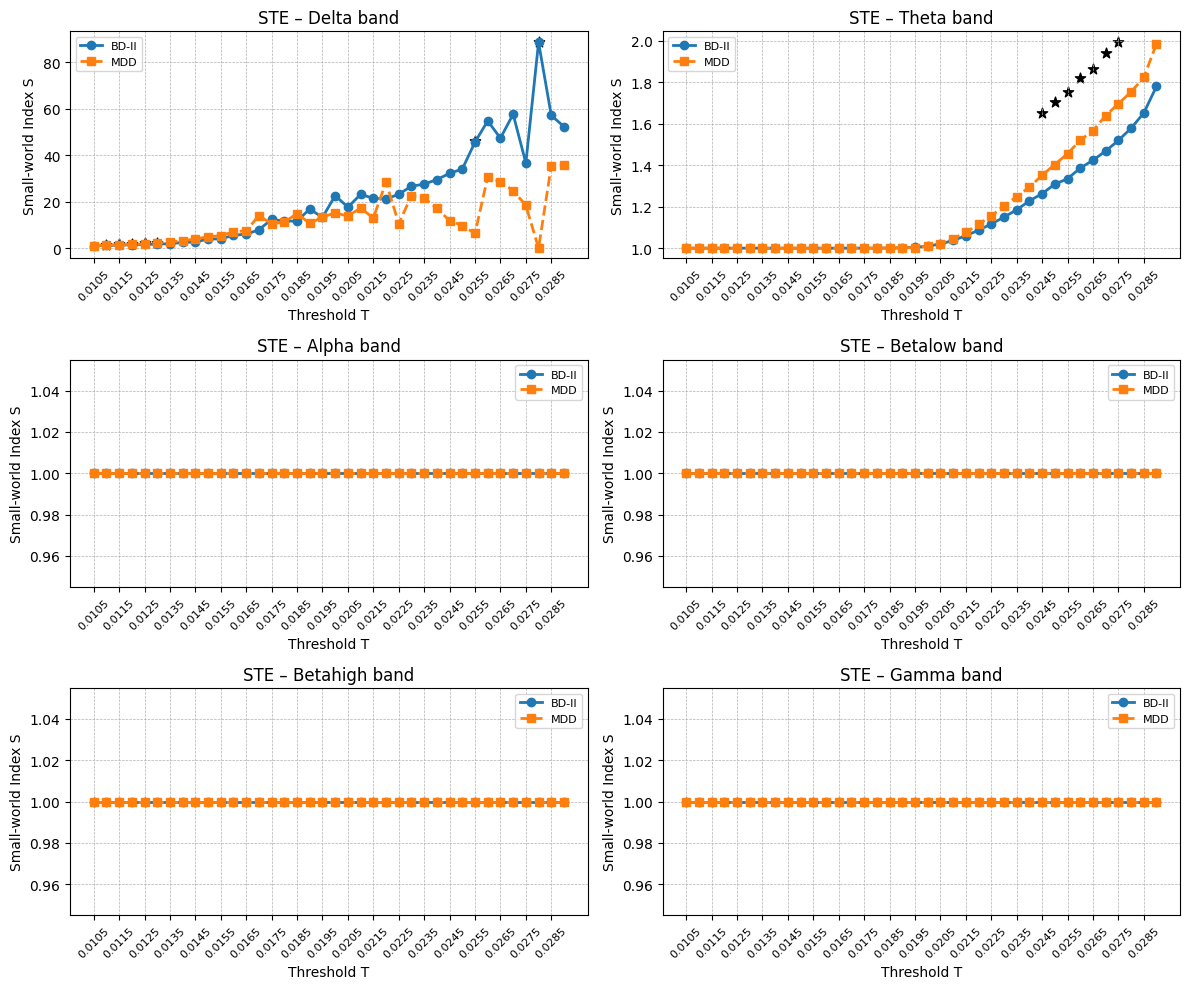

In [ ]:
summary_ste = {band: {} for band in freqs}
signif_ste  = {band: [] for band in freqs}

for band in freqs:
    for T in thresholds:
        mb = metrics_BD[band][T]
        mm = metrics_MDD[band][T]
        if not mb['S'] or not mm['S']:
            summary_ste[band][T] = None
            signif_ste[band].append(False)
            continue

        # 計算群組平均 S
        mS_b = np.mean(mb['S'])
        mS_m = np.mean(mm['S'])

        # 非配對 t 檢定
        stat, p = ttest_ind(mb['S'], mm['S'], equal_var=False)
        flag = (p < 0.05)
        signif_ste[band].append(flag)

        summary_ste[band][T] = {
            'mean_S_BD':  mS_b,
            'mean_S_MDD': mS_m,
            't_stat':     stat,
            'p_val':      p
        }

# plot
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, band in zip(axes, freqs):

    x     = thresholds[20:58]
    y_bd  = [summary_ste[band][T]['mean_S_BD']  if summary_ste[band][T] else np.nan for T in x]
    y_mdd = [summary_ste[band][T]['mean_S_MDD'] if summary_ste[band][T] else np.nan for T in x]
    sigs  = signif_ste[band][20:58]

    ax.plot(x, y_bd,  label='BD-II', linewidth=2, marker='o')
    ax.plot(x, y_mdd, linestyle='--', label='MDD', linewidth=2, marker='s')

    # star
    for xi, bd_i, mdd_i, sig in zip(x, y_bd, y_mdd, sigs):
        if sig:
            y_star = max(bd_i, mdd_i) + 0.3
            ax.scatter(xi, y_star, marker='*', color='black', s=60)

    ax.set_xticks(x[::2])
    ax.set_xticklabels([f"{t:.4f}" for t in x[::2]], rotation=45, fontsize=8)
    ax.grid(True, which='major', linestyle='--', linewidth=0.5)

    ax.set_title(f'STE – {band.capitalize()} band')
    ax.set_xlabel('Threshold T')
    ax.set_ylabel('Small-world Index S')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

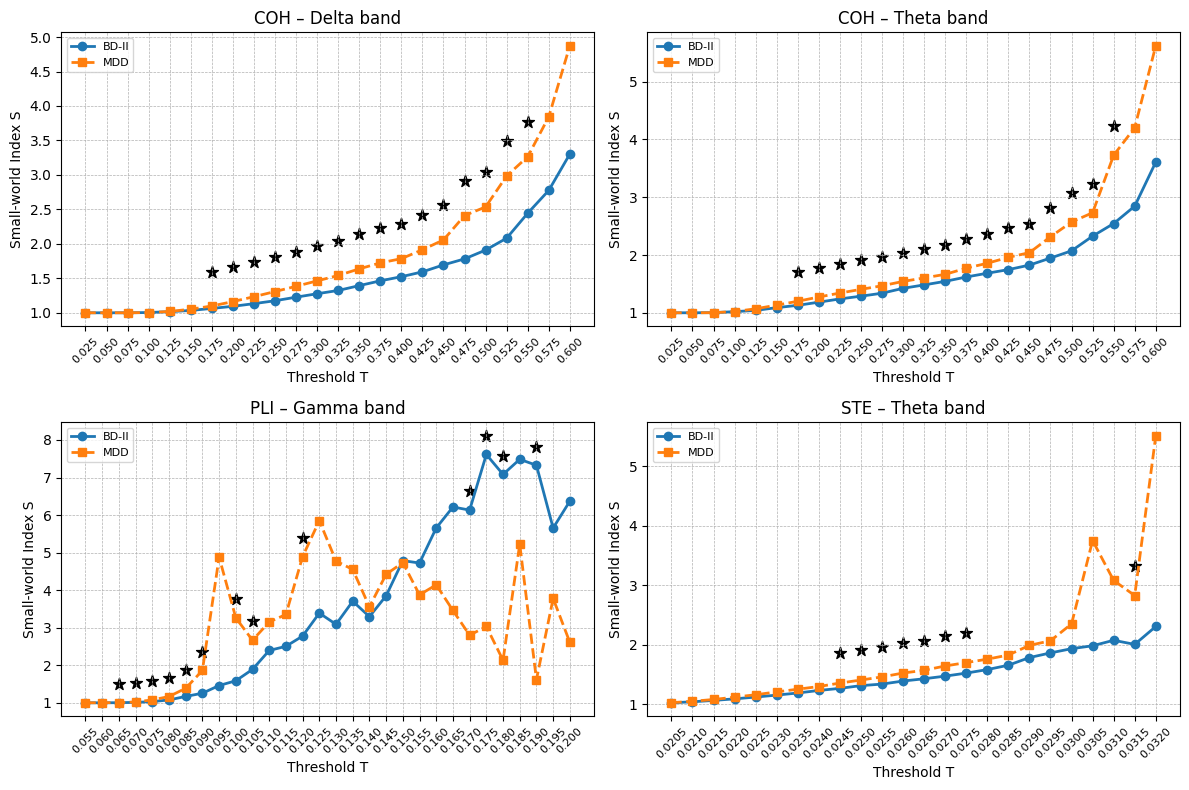

In [ ]:
thresholds_coh = np.arange(0.025, 0.7,   0.025)    
thresholds_pli = np.arange(0.005, 0.4,   0.005)
thresholds_ste = np.arange(0.0005, 0.3,  0.0005)

plots = [
    ("COH",  "delta",  thresholds_coh[:24], summary_coh, signif_coh["delta"][:24], (0.8, 1.2)),
    ("COH",  "theta",  thresholds_coh[:24], summary_coh, signif_coh["delta"][:24], (0.7, 1.1)),
    ("PLI",  "gamma",  thresholds_pli[10:40], summary_pli, signif_pli["gamma"][10:40], (0.9, 1.3)),
    ("STE",  "theta",  thresholds_ste[40:64], summary_ste, signif_ste["theta"][40:64], (0.6, 1.4)),
]


fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)
axes = axes.flatten()

for ax, (kind, band, xs, sum_dict, sig_list, ylim_range) in zip(axes, plots):
    
    y_bd  = [ sum_dict[band][T]['mean_S_BD']   if sum_dict[band].get(T) else np.nan for T in xs ]
    y_mdd = [ sum_dict[band][T]['mean_S_MDD']  if sum_dict[band].get(T) else np.nan for T in xs ]


    
    ax.plot(xs, y_bd,  label="BD-II", linewidth=2, marker="o")
    ax.plot(xs, y_mdd, linestyle="--", label="MDD", linewidth=2, marker="s")

    
    for T, bd_i, mdd_i, sig in zip(xs, y_bd, y_mdd, sig_list):
        if sig:
            y_star = max(bd_i, mdd_i) + 0.5
            ax.scatter(T, y_star, marker="*", s=80, color="black")

    if kind == "STE":
        ticks = xs
        labels = [f"{t:.4f}" for t in ticks]
    else:
        ticks = xs
        labels = [f"{t:.3f}" for t in xs]

    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, rotation=45, fontsize=8)

    ax.grid(True, which='major', linestyle='--', linewidth=0.5)
    ax.set_title(f"{kind} – {band.capitalize()} band")
    ax.set_xlabel("Threshold T")
    ax.set_ylabel("Small-world Index S")
    # ax.set_ylim(*ylim_range)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", linewidth=0.5)

plt.tight_layout()
# plt.savefig("../result_FA/svalue/summary_plots.png", dpi=300)
plt.show()
